In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from astropy.io import fits

In [2]:
FUGIN_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01100+0000_2x2_12CO_v1.00_cube.fits"
bubble_rabge_storage = np.load("bubble_range_storage.npz")

In [3]:
hdu = fits.open(FUGIN_path)[0]
header = hdu.header

In [7]:
loaded_list = [bubble_rabge_storage[key] for key in bubble_rabge_storage.files]

In [8]:
loaded_sum_list = [len(array) for array in loaded_list]
velocity_sum_list = [val*header["CDELT3"]/1000 for val in loaded_sum_list]

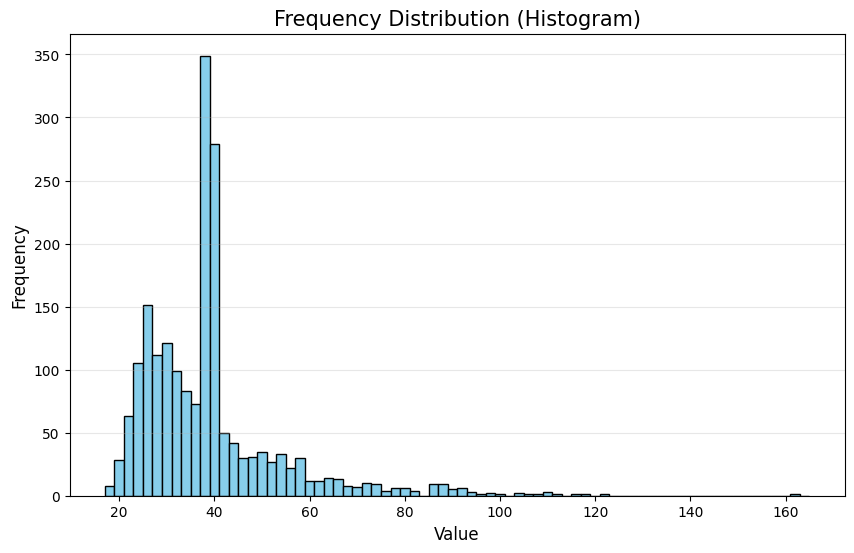

In [27]:
plt.figure(figsize=(10, 6))
# bins: 棒の数。rangeで最小値から最大値まで指定。
plt.hist(loaded_sum_list, bins=range(min(loaded_sum_list), max(loaded_sum_list) + 5, 2), color='skyblue', edgecolor='black')
plt.title('Frequency Distribution (Histogram)', fontsize=15)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig("bubble_Histogram.svg")
plt.show()

In [26]:
s = pd.Series(loaded_sum_list)

# 階級幅（例：10刻み）でカット
bins = range(min(loaded_sum_list)//10*10, (max(loaded_sum_list)//10+2)*10, 10)
frequency_table = pd.cut(s, bins=bins).value_counts().sort_index().reset_index()
frequency_table.columns = ['Range', 'Frequency']

# 割合(%)も追加
frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(loaded_sum_list) * 100).round(1)

print(frequency_table)

         Range  Frequency  Percentage (%)
0     (10, 20]         36             1.9
1     (20, 30]        552            28.7
2     (30, 40]        883            45.9
3     (40, 50]        188             9.8
4     (50, 60]        124             6.4
5     (60, 70]         54             2.8
6     (70, 80]         35             1.8
7     (80, 90]         27             1.4
8    (90, 100]         13             0.7
9   (100, 110]          7             0.4
10  (110, 120]          3             0.2
11  (120, 130]          1             0.1
12  (130, 140]          0             0.0
13  (140, 150]          0             0.0
14  (150, 160]          0             0.0
15  (160, 170]          1             0.1
